### LPPLS calibration as implemented in the lppls python package

In [ ]:
from multiprocessing import Pool
from matplotlib import pyplot as plt
from numba import njit
import numpy as np
import pandas as pd
import random
from datetime import datetime as date
from pandas._libs.tslibs.np_datetime import OutOfBoundsDatetime
from scipy.optimize import minimize
from tqdm import tqdm
import xarray as xr

In [ ]:
def matrix_equation(observations, tc, m, w):
    """
    Derive linear parameters in LPPLs from nonlinear ones.
    """
    # T = observations[0]
    # P = observations[1]
    
    T = observations.index.values
    P = observations.values
    N = len(T)

    dT = np.abs(tc - T) + 1e-8
    phase = np.log(dT)

    fi = np.power(dT, m)
    gi = fi * np.cos(w * phase)
    hi = fi * np.sin(w * phase)

    fi_pow_2 = np.power(fi, 2)
    gi_pow_2 = np.power(gi, 2)
    hi_pow_2 = np.power(hi, 2)

    figi = np.multiply(fi, gi)
    fihi = np.multiply(fi, hi)
    gihi = np.multiply(gi, hi)

    yi = P
    yifi = np.multiply(yi, fi)
    yigi = np.multiply(yi, gi)
    yihi = np.multiply(yi, hi)

    matrix_1 = np.array(
        [
            [N, np.sum(fi), np.sum(gi), np.sum(hi)],
            [np.sum(fi), np.sum(fi_pow_2), np.sum(figi), np.sum(fihi)],
            [np.sum(gi), np.sum(figi), np.sum(gi_pow_2), np.sum(gihi)],
            [np.sum(hi), np.sum(fihi), np.sum(gihi), np.sum(hi_pow_2)],
        ]
    )

    matrix_2 = np.array(
        [[np.sum(yi)], [np.sum(yifi)], [np.sum(yigi)], [np.sum(yihi)]]
    )

    matrix_1 += 1e-8 * np.eye(matrix_1.shape[0])

    return np.linalg.solve(matrix_1, matrix_2)

<Axes: >

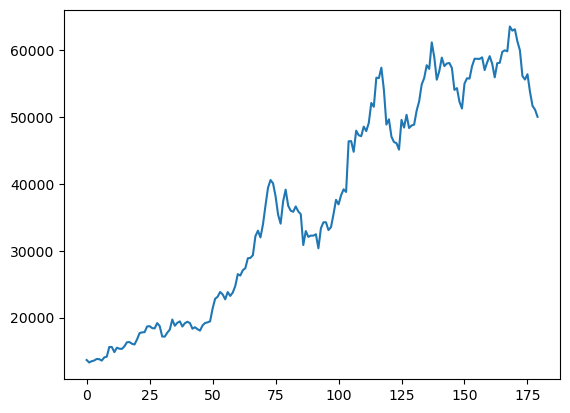

In [32]:
PAIR = 'BTC_USDT'
TIMEFRAME = '1d'

EXCHANGE = 'binance'

odf = pd.read_json(f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{EXCHANGE}/{PAIR}-{TIMEFRAME}.json'
# exchange = 'kucoin'
# odf = pd.read_json(f'../../freq-user-data/data/{exchange}/futures/{pair}-{timeframe}-futures.json'
).dropna().set_axis(['timestamp', 'open', 'high', 'low', 'close', 'volume'], axis=1
).assign(dtime=lambda x: pd.to_datetime(x['timestamp'], unit='ms', utc=False)
).drop('timestamp', axis=1
).set_index('dtime')#.sort_index()

ws = 300
ww = 180
y = odf.iloc[ws:ws+ww].reset_index().close
y.plot()

In [35]:
y.shape[0]-1

180

In [44]:

tc,m,w = (y.shape[0]-1),0.5,8
seed = [tc,m,w]
observations = y#.values
rM = matrix_equation(observations, tc, m, w)
rM


array([[77964.51079239],
       [-4523.05308925],
       [  181.16560276],
       [ -179.17130131]])

In [58]:

    T = observations.index.values
    P = observations.values
    N = len(T)

    dT = np.abs(tc - T) + 1e-8
    phase = np.log(dT)

    fi = np.power(dT, m)
    gi = fi * np.cos(w * phase)
    hi = fi * np.sin(w * phase)

    fi_pow_2 = np.power(fi, 2)
    gi_pow_2 = np.power(gi, 2)
    hi_pow_2 = np.power(hi, 2)
# print('---fi_pow_2[0],gi_pow_2[0],hi_pow_2[0]')    
# print(fi_pow_2[0],gi_pow_2[0],hi_pow_2[0])
# print(fi_pow_2[-1],gi_pow_2[-1],hi_pow_2[-1])
    figi = np.multiply(fi, gi)
    fihi = np.multiply(fi, hi)
    gihi = np.multiply(gi, hi)
# print('---figi[0],gihi[0],fihi[0]')
# print(figi[0],gihi[0],fihi[0])
# print(figi[-1],gihi[-1],fihi[-1])
    yi = P
    yifi = np.multiply(yi, fi)
    yigi = np.multiply(yi, gi)
    yihi = np.multiply(yi, hi)
# print('---yi[0],yifi[0],yigi[0],yihi[0]')
# print(yi[0],yifi[0],yigi[0],yihi[0])
# print(yi[-1],yifi[-1],yigi[-1],yihi[-1])
# print(fihi)
    # matrix_1 = np.array(
    #     [
    #         [N, np.sum(fi), np.sum(gi), np.sum(hi)],
    #         [np.sum(fi), np.sum(fi_pow_2), np.sum(figi), np.sum(fihi)],
    #         [np.sum(gi), np.sum(figi), np.sum(gi_pow_2), np.sum(gihi)],
    #         [np.sum(hi), np.sum(fihi), np.sum(gihi), np.sum(hi_pow_2)],
    #     ]
    # )
# print(matrix_1)
    # matrix_2 = np.array(
    #     [[np.sum(yi)], [np.sum(yifi)], [np.sum(yigi)], [np.sum(yihi)]]
    # )

    # matrix_1 += 1e-8 * np.eye(matrix_1.shape[0])

    # return np.linalg.solve(matrix_1, matrix_2)

[-1.09518967e+02 -1.02489724e+02 -9.52902508e+01 -8.79342511e+01
 -8.04359892e+01 -7.28102759e+01 -6.50724506e+01 -5.72383622e+01
 -4.93243477e+01 -4.13472083e+01 -3.33241841e+01 -2.52729261e+01
 -1.72114662e+01 -9.15818439e+00 -1.13177480e+00  6.84879182e+00
  1.47643072e+01  2.25953673e+01  3.03224164e+01  3.79257932e+01
  4.53857801e+01  5.26826535e+01  5.97967382e+01  6.67084619e+01
  7.33984140e+01  7.98474050e+01  8.60365288e+01  9.19472266e+01
  9.75613531e+01  1.02861244e+02  1.07829785e+02  1.12450483e+02
  1.16707539e+02  1.20585921e+02  1.24071435e+02  1.27150805e+02
  1.29811746e+02  1.32043040e+02  1.33834610e+02  1.35177595e+02
  1.36064430e+02  1.36488911e+02  1.36446272e+02  1.35933255e+02
  1.34948174e+02  1.33490985e+02  1.31563343e+02  1.29168665e+02
  1.26312179e+02  1.23000975e+02  1.19244050e+02  1.15052345e+02
  1.10438775e+02  1.05418254e+02  1.00007712e+02  9.42261022e+01
  8.80943985e+01  8.16355867e+01  7.48746417e+01  6.78384949e+01
  6.05559898e+01  5.30578